In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from bart_playground import DefaultBART, ParallelTemperingBART, DataGenerator
import cProfile
import pstats
import io
import time

In [3]:
# PT vs DefaultBART benchmark settings
proposal_probs = {"grow": 0.4, "prune": 0.4, "change": 0.1, "swap": 0.1}
generator = DataGenerator(n_samples=1000, n_features=10, noise=0.1, random_seed=42)
X, y = generator.generate(scenario="heteroscedastic")
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

default_kwargs = dict(
    ndpost=800,
    nskip=200,
    n_trees=100,
    proposal_probs=proposal_probs,
    random_state=42,
    max_bins=100,
    tol=1,
    quick_decay=False,
    dirichlet_prior=False,
    temperature=1.0,
 )

# PT kwargs template (hard-coded temperatures set in next cell)
pt_kwargs = dict(
    ndpost=800,
    nskip=200,
    n_trees=100,
    proposal_probs=proposal_probs,
    random_state=42,
    max_bins=100,
    tol=1,
    quick_decay=False,
    dirichlet_prior=False,
    swap_interval=50,
    swap_sweeps=2,
    post_swap_repair_steps=0,
    store_chain_traces=False,
    store_swap_diagnostics=True,
    # print_swap_diagnostics=True,
    n_temperatures=8, max_temperature=5.0, 
    n_jobs=-1,
    local_move_backend="multiprocessing-pipe",  # or "joblib-loky"
 )

In [4]:
# initialize numba (warmup)
warmup_default = DefaultBART(ndpost=5, nskip=5, n_trees=20, proposal_probs=proposal_probs, random_state=7)
_ = warmup_default.fit(X_train[:800], y_train[:800], quietly=True)

warmup_pt = ParallelTemperingBART(
    ndpost=5, nskip=5, n_trees=20, proposal_probs=proposal_probs,
    random_state=7, n_temperatures=3, max_temperature=3.0, swap_interval=5
 )
_ = warmup_pt.fit(X_train[:800], y_train[:800], quietly=True)

print("Numba warmup completed.")

Numba warmup completed.


In [5]:
# helper: format cProfile output
def profile_summary(profiler, top_n=20, sort_key="cumtime"):
    s = io.StringIO()
    pstats.Stats(profiler, stream=s).sort_stats(sort_key).print_stats(top_n)
    return s.getvalue()

# helper: compare RMSE across trained models
def compare_rmse(models, X, y):
    import pandas as pd
    rows = []
    for name, model in models.items():
        rmse = root_mean_squared_error(y, model.predict(X))
        rows.append({"model": name, "rmse": rmse})
    return pd.DataFrame(rows).sort_values("rmse", ascending=True).reset_index(drop=True)

# --- DefaultBART fit + profile ---
default_model = DefaultBART(**default_kwargs)
default_profiler = cProfile.Profile()
t0 = time.perf_counter()
default_profiler.enable()
default_model.fit(X_train, y_train)
default_profiler.disable()
default_fit_seconds = time.perf_counter() - t0
default_profile_text = profile_summary(default_profiler, top_n=20)

# --- ParallelTemperingBART fit + profile ---
pt_model = ParallelTemperingBART(**pt_kwargs)
pt_profiler = cProfile.Profile()
t0 = time.perf_counter()
pt_profiler.enable()
pt_model.fit(X_train, y_train)
pt_profiler.disable()
pt_fit_seconds = time.perf_counter() - t0
pt_profile_text = profile_summary(pt_profiler, top_n=20)

# RMSE comparison via function
rmse_df = compare_rmse(
    {
        "DefaultBART": default_model,
        "ParallelTemperingBART": pt_model,
    },
    X_test,
    y_test,
)

# speed + rmse summary
import pandas as pd
fit_df = pd.DataFrame({
    "model": ["DefaultBART", "ParallelTemperingBART"],
    "fit_seconds": [default_fit_seconds, pt_fit_seconds],
})
fit_df["speedup_vs_default"] = fit_df.loc[0, "fit_seconds"] / fit_df["fit_seconds"]

summary_df = fit_df.merge(rmse_df, on="model", how="left")
print(summary_df)

Iterations: 100%|██████████| 1000/1000 [00:28<00:00, 35.40it/s]


                   model  fit_seconds  speedup_vs_default      rmse
0            DefaultBART    15.178366            1.000000  1.899877
1  ParallelTemperingBART    54.708006            0.277443  1.841089


In [6]:
print("\n=== Top-20 cProfile (DefaultBART) ===")
print(default_profile_text)
print("\n=== Top-20 cProfile (ParallelTemperingBART) ===")
print(pt_profile_text)

pt_params = pt_model.get_params()
print("\nPT temperatures:")
for i, t in enumerate(pt_params.get("temperatures", [])):
    print(f"chain {i}: T={t:.6g}")

print("\nPT swap stats:")
print(pt_params.get("swap_attempts"), pt_params.get("swap_accept_rates"))


=== Top-20 cProfile (DefaultBART) ===
         7705334 function calls (7705326 primitive calls) in 15.178 seconds

   Ordered by: cumulative time
   List reduced from 539 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000   15.178    7.589 c:\Users\ztykk\Phd\BART\bart-playground\.venv\lib\site-packages\IPython\core\interactiveshell.py:3543(run_code)
        2    0.000    0.000   15.178    7.589 {built-in method builtins.exec}
        1    0.000    0.000   15.178   15.178 C:\Users\ztykk\Phd\BART\bart-playground\bart_playground\bart.py:193(fit)
        1    0.000    0.000   15.176   15.176 C:\Users\ztykk\Phd\BART\bart-playground\bart_playground\bart.py:200(fit_with_data)
        1    0.055    0.055   15.176   15.176 C:\Users\ztykk\Phd\BART\bart-playground\bart_playground\samplers.py:93(run)
     1000    1.143    0.001   14.433    0.014 C:\Users\ztykk\Phd\BART\bart-playground\bart_playground\samplers.py:351(o

In [7]:
print("\nPT swap stats (attempt/accept rate by adjacent pair):")
print(pt_params.get("swap_attempts"), pt_params.get("swap_accept_rates"))

diags = pt_params.get("swap_diagnostics", None)
if not diags:
    print("\nNo swap_diagnostics found. Set store_swap_diagnostics=True and rerun PT fit.")
else:
    import pandas as pd
    diag_df = pd.DataFrame(diags).copy()
    diag_df["accepted"] = diag_df["accepted"].astype(bool)

    # Keep key columns and sort so the swap schedule is easy to read
    show_cols = [
        "iteration", "swap_step", "sweep", "pair_index",
        "temp_a", "temp_b", "delta", "accepted",
    ]
    for c in ["iteration", "swap_step", "sweep", "pair_index"]:
        if c in diag_df.columns:
            diag_df[c] = diag_df[c].astype("Int64")

    diag_view = diag_df[show_cols].sort_values(["iteration", "sweep", "pair_index"]).reset_index(drop=True)

    print("\nSwap diagnostics preview (first 20 attempts):")
    print(diag_view.head(20))

    # Aggregate acceptance by sweep index inside each swap step
    by_sweep = (
        diag_df.groupby(["swap_step", "sweep", "pair_index"], as_index=False)
        .agg(attempts=("accepted", "size"), accepts=("accepted", "sum"))
    )
    by_sweep["accept_rate"] = by_sweep["accepts"] / by_sweep["attempts"]

    print("\nAcceptance by (swap_step, sweep, pair_index):")
    print(by_sweep.head(30))

    # Overall acceptance by sweep number (across all swap steps/pairs)
    sweep_summary = (
        diag_df.groupby("sweep", as_index=False)
        .agg(attempts=("accepted", "size"), accepts=("accepted", "sum"))
    )
    sweep_summary["accept_rate"] = sweep_summary["accepts"] / sweep_summary["attempts"]

    print("\nOverall acceptance by sweep index:")
    print(sweep_summary)


PT swap stats (attempt/accept rate by adjacent pair):
[16, 16, 16, 16, 16, 16, 16] [0.8125, 0.875, 0.875, 0.75, 0.75, 0.9375, 0.875]

Swap diagnostics preview (first 20 attempts):
    iteration  swap_step  sweep  pair_index    temp_a    temp_b      delta  \
0          50          1      1           1  1.258499  1.583820  -2.738897   
1          50          1      1           3  1.993235  2.508485  -3.413148   
2          50          1      1           5  3.156925  3.972987   0.745225   
3          50          1      2           0  1.000000  1.258499 -11.605628   
4          50          1      2           2  1.583820  1.993235  10.771519   
5          50          1      2           4  2.508485  3.156925   8.845494   
6          50          1      2           6  3.972987  5.000000  -1.498104   
7         100          2      1           0  1.000000  1.258499   4.259771   
8         100          2      1           2  1.583820  1.993235   1.830863   
9         100          2      1        

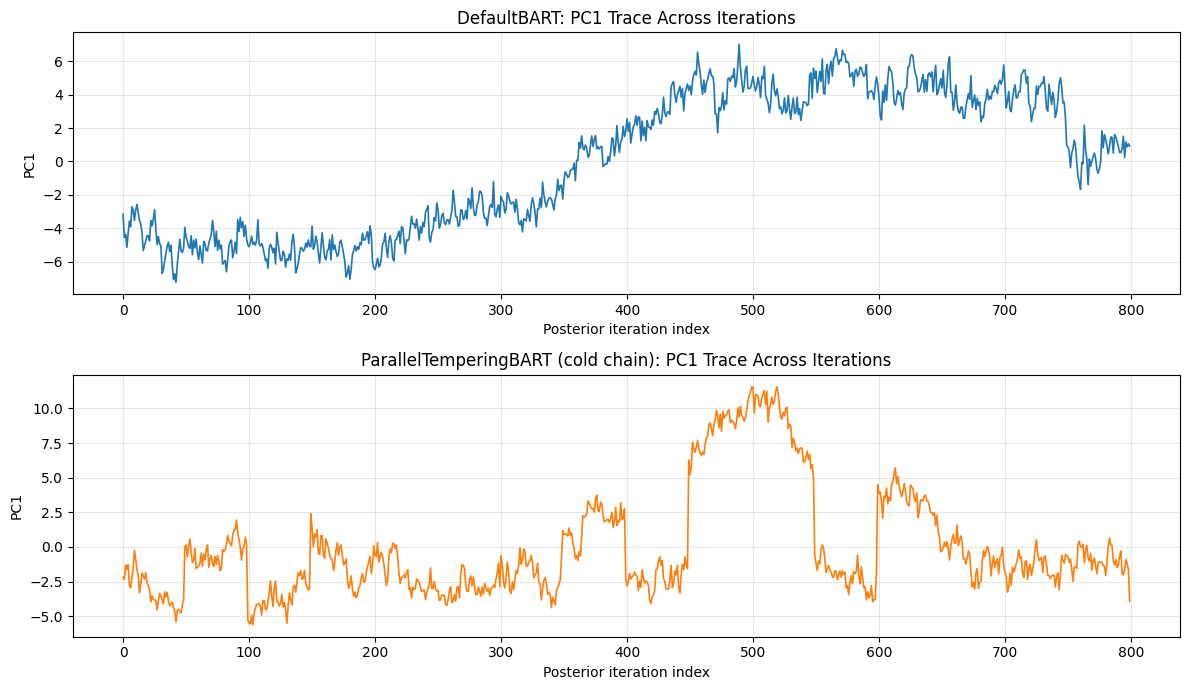

default_pred_mat shape: (800, 250)
pt_pred_mat shape: (800, 250)


In [8]:
# Per-iteration prediction traces -> PCA(1D) -> trace plot
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def posterior_pred_matrix(model, X):
    # Shape: (n_iterations, n_samples)
    mat = np.stack([model.predict_trace(k, X) for k in model.range_post], axis=0)
    return mat

default_pred_mat = posterior_pred_matrix(default_model, X_test)
pt_pred_mat = posterior_pred_matrix(pt_model, X_test)

default_pc1 = PCA(n_components=1).fit_transform(default_pred_mat).ravel()
pt_pc1 = PCA(n_components=1).fit_transform(pt_pred_mat).ravel()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
axes[0].plot(default_pc1, lw=1.2)
axes[0].set_title("DefaultBART: PC1 Trace Across Iterations")
axes[0].set_xlabel("Posterior iteration index")
axes[0].set_ylabel("PC1")
axes[0].grid(alpha=0.3)

axes[1].plot(pt_pc1, lw=1.2, color="tab:orange")
axes[1].set_title("ParallelTemperingBART (cold chain): PC1 Trace Across Iterations")
axes[1].set_xlabel("Posterior iteration index")
axes[1].set_ylabel("PC1")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("default_pred_mat shape:", default_pred_mat.shape)
print("pt_pred_mat shape:", pt_pred_mat.shape)

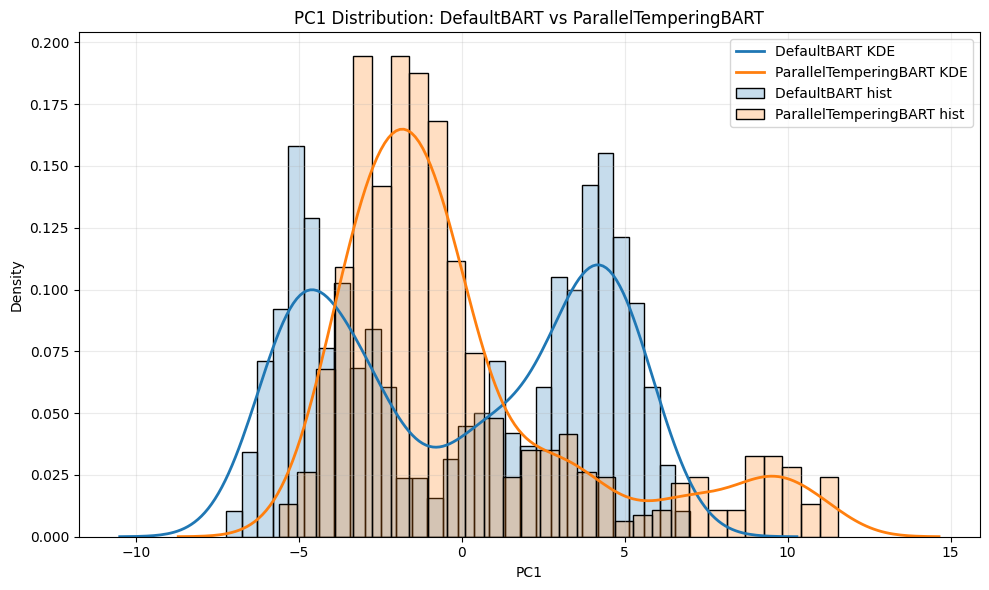

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram (density) + KDE for each method
sns.histplot(
    default_pc1,
    bins=30,
    stat="density",
    alpha=0.25,
    color="tab:blue",
    label="DefaultBART hist",
    ax=ax,
)
sns.kdeplot(
    default_pc1,
    color="tab:blue",
    linewidth=2,
    label="DefaultBART KDE",
    ax=ax,
)

sns.histplot(
    pt_pc1,
    bins=30,
    stat="density",
    alpha=0.25,
    color="tab:orange",
    label="ParallelTemperingBART hist",
    ax=ax,
)
sns.kdeplot(
    pt_pc1,
    color="tab:orange",
    linewidth=2,
    label="ParallelTemperingBART KDE",
    ax=ax,
)

ax.set_title("PC1 Distribution: DefaultBART vs ParallelTemperingBART")
ax.set_xlabel("PC1")
ax.set_ylabel("Density")
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

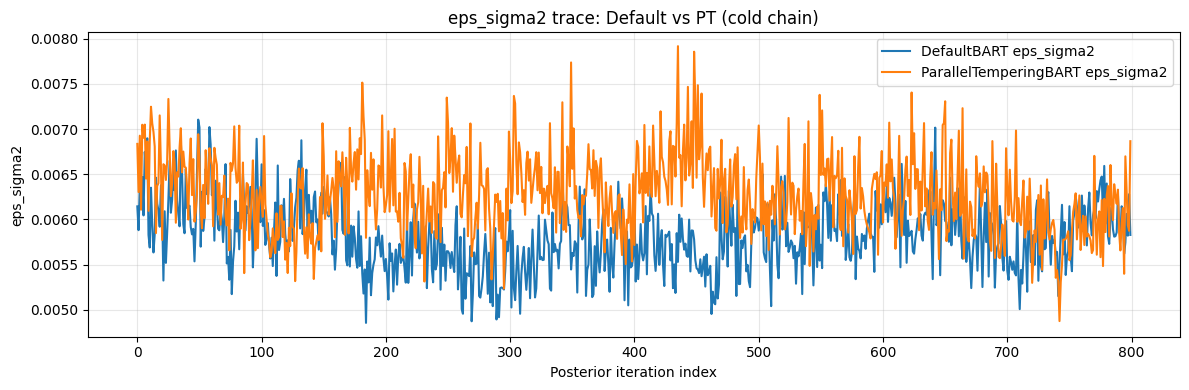

In [10]:
import matplotlib.pyplot as plt
import numpy as np

sigma_default = np.array([np.asarray(t.global_params['eps_sigma2']).ravel()[0]
                          for t in default_model.trace])
sigma_pt = np.array([np.asarray(t.global_params['eps_sigma2']).ravel()[0]
                     for t in pt_model.trace])

plt.figure(figsize=(12, 4))
plt.plot(sigma_default, label='DefaultBART eps_sigma2')
plt.plot(sigma_pt, label='ParallelTemperingBART eps_sigma2')
plt.xlabel('Posterior iteration index')
plt.ylabel('eps_sigma2')
plt.title('eps_sigma2 trace: Default vs PT (cold chain)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

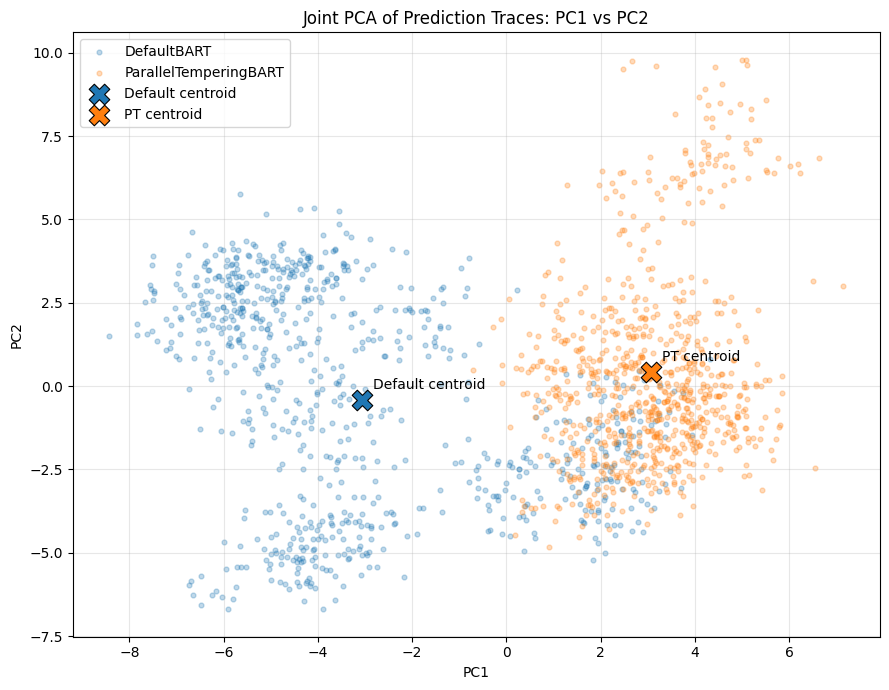

Explained variance ratio: [0.06995508 0.04444595]
Default centroid: [-3.07010751 -0.42764322]
PT centroid: [3.07010751 0.42764322]


In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# default_pred_mat, pt_pred_mat are expected from the previous cell.
# Shape convention: (n_iterations, n_test_samples)
combined_preds = np.vstack([default_pred_mat, pt_pred_mat])
labels = np.array(
    ["DefaultBART"] * default_pred_mat.shape[0] +
    ["ParallelTemperingBART"] * pt_pred_mat.shape[0]
 )

pca2 = PCA(n_components=2, random_state=42)
coords = pca2.fit_transform(combined_preds)

coords_default = coords[labels == "DefaultBART"]
coords_pt = coords[labels == "ParallelTemperingBART"]

centroid_default = coords_default.mean(axis=0)
centroid_pt = coords_pt.mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    coords_default[:, 0], coords_default[:, 1],
    s=12, alpha=0.28, label="DefaultBART", color="tab:blue"
 )
ax.scatter(
    coords_pt[:, 0], coords_pt[:, 1],
    s=12, alpha=0.28, label="ParallelTemperingBART", color="tab:orange"
 )

# Mark centroids
ax.scatter(
    centroid_default[0], centroid_default[1],
    s=220, marker="X", color="tab:blue", edgecolor="black", linewidth=0.8,
    label="Default centroid"
 )
ax.scatter(
    centroid_pt[0], centroid_pt[1],
    s=220, marker="X", color="tab:orange", edgecolor="black", linewidth=0.8,
    label="PT centroid"
 )

ax.annotate("Default centroid", (centroid_default[0], centroid_default[1]),
            xytext=(8, 8), textcoords="offset points")
ax.annotate("PT centroid", (centroid_pt[0], centroid_pt[1]),
            xytext=(8, 8), textcoords="offset points")

ax.set_title("Joint PCA of Prediction Traces: PC1 vs PC2")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca2.explained_variance_ratio_)
print("Default centroid:", centroid_default)
print("PT centroid:", centroid_pt)